In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/nasa-cmaps/CMaps/RUL_FD002.txt
/kaggle/input/nasa-cmaps/CMaps/test_FD003.txt
/kaggle/input/nasa-cmaps/CMaps/Damage Propagation Modeling.pdf
/kaggle/input/nasa-cmaps/CMaps/readme.txt
/kaggle/input/nasa-cmaps/CMaps/train_FD003.txt
/kaggle/input/nasa-cmaps/CMaps/test_FD004.txt
/kaggle/input/nasa-cmaps/CMaps/train_FD004.txt
/kaggle/input/nasa-cmaps/CMaps/x.txt
/kaggle/input/nasa-cmaps/CMaps/test_FD002.txt
/kaggle/input/nasa-cmaps/CMaps/train_FD001.txt
/kaggle/input/nasa-cmaps/CMaps/train_FD002.txt
/kaggle/input/nasa-cmaps/CMaps/RUL_FD001.txt
/kaggle/input/nasa-cmaps/CMaps/RUL_FD004.txt
/kaggle/input/nasa-cmaps/CMaps/RUL_FD003.txt
/kaggle/input/nasa-cmaps/CMaps/test_FD001.txt
/kaggle/input/nasa-cmaps/cmaps/CMaps/RUL_FD002.txt
/kaggle/input/nasa-cmaps/cmaps/CMaps/test_FD003.txt
/kaggle/input/nasa-cmaps/cmaps/CMaps/Damage Propagation Modeling.pdf
/kaggle/input/nasa-cmaps/cmaps/CMaps/readme.txt
/kaggle/input/nasa-cmaps/cmaps/CMaps/train_FD003.txt
/kaggle/input/nasa-cmaps/cmaps/CM

# RULForge — Predictive Maintenance Baseline (C-MAPSS)

**TL;DR** Predict Remaining Useful Life (RUL) for turbofan engines and choose a maintenance **alert threshold** by **Net Benefit** (downtime vs inspection cost).  
We auto-detect an FD set (prefer **FD001**), build rolling-window features, fit a **Ridge** baseline with **GroupKFold**, and sweep thresholds *T*.

**Users:** maintenance planners, line supervisors  
**Decision:** if predicted RUL < **T** cycles → schedule inspection  
**Artifacts:** `ridge_[fd].joblib`, `meta_[fd].json` (CV RMSE, chosen T, costs)

---

### Table of Contents
1. [Setup & Config](#1-setup--config)  
2. [Dataset & File Discovery](#2-dataset--file-discovery)  
3. [Leakage Policy & RUL Labels](#3-leakage-policy--rul-labels)  
4. [Feature Engineering (rolling window)](#4-feature-engineering-rolling-window)  
5. [Validation & Baseline Model](#5-validation--baseline-model)  
6. [Business Metric: Net Benefit](#6-business-metric-net-benefit)  
7. [Results & Takeaways](#7-results--takeaways)  
8. [Artifacts & Reuse](#8-artifacts--reuse)  
   


# === 1) Setup & Config ========================================================


In [2]:
import os, pathlib, numpy as np, pandas as pd
from pathlib import Path
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt

DATA_DIR = Path("/kaggle/input")  # Kaggle mounts datasets here
WORK_DIR = Path("/kaggle/working")


In [3]:
# Adjust the subfolder name to the dataset you added if needed
# Peek inside /kaggle/input to see exact folder name
list(DATA_DIR.iterdir())[:3]

[PosixPath('/kaggle/input/nasa-cmaps')]

# === 2) Dataset & File Discovery (auto-detect FD set, read CSVs) ==============


In [4]:
CMAPSS = next(p for p in DATA_DIR.iterdir() if p.is_dir() and "fd001" in " ".join(os.listdir(p)).lower() or True)

col_names = (["engine_id","cycle"] +
             [f"op_setting_{i}" for i in range(1,4)] +
             [f"s{i}" for i in range(1,22)])

train_path = None
test_path  = None
rul_path   = None

# Find the 3 files inside the dataset
for p in CMAPSS.rglob("*"):
    name = p.name.lower()
    if "train_fd001" in name and name.endswith(".txt"): train_path = p
    if "test_fd001"  in name and name.endswith(".txt"): test_path  = p
    if "rul_fd001"   in name and name.endswith(".txt"): rul_path   = p

assert train_path and test_path and rul_path, "FD001 files not found — check dataset paths."

train = pd.read_csv(train_path, sep=r"\s+", header=None, names=col_names)
test  = pd.read_csv(test_path,  sep=r"\s+", header=None, names=col_names)
rul   = pd.read_csv(rul_path,   sep=r"\s+", header=None, names=["RUL"])

train.head(), train.shape, test.shape, rul.shape

(   engine_id  cycle  op_setting_1  op_setting_2  op_setting_3      s1      s2  \
 0          1      1       -0.0007       -0.0004         100.0  518.67  641.82   
 1          1      2        0.0019       -0.0003         100.0  518.67  642.15   
 2          1      3       -0.0043        0.0003         100.0  518.67  642.35   
 3          1      4        0.0007        0.0000         100.0  518.67  642.35   
 4          1      5       -0.0019       -0.0002         100.0  518.67  642.37   
 
         s3       s4     s5  ...     s12      s13      s14     s15   s16  s17  \
 0  1589.70  1400.60  14.62  ...  521.66  2388.02  8138.62  8.4195  0.03  392   
 1  1591.82  1403.14  14.62  ...  522.28  2388.07  8131.49  8.4318  0.03  392   
 2  1587.99  1404.20  14.62  ...  522.42  2388.03  8133.23  8.4178  0.03  390   
 3  1582.79  1401.87  14.62  ...  522.86  2388.08  8133.83  8.3682  0.03  392   
 4  1582.85  1406.22  14.62  ...  522.19  2388.04  8133.80  8.4294  0.03  393   
 
     s18    s19   

# === 3) Labels & EDA ==========================================================


In [5]:
def add_rul_labels(df):
    # RUL = last_cycle_per_engine - cycle
    last = df.groupby("engine_id")["cycle"].max().rename("last_cycle")
    df = df.join(last, on="engine_id")
    df["RUL"] = df["last_cycle"] - df["cycle"]
    return df.drop(columns=["last_cycle"])

train = add_rul_labels(train)
train[["engine_id","cycle","RUL"]].head()


,engine_id,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187


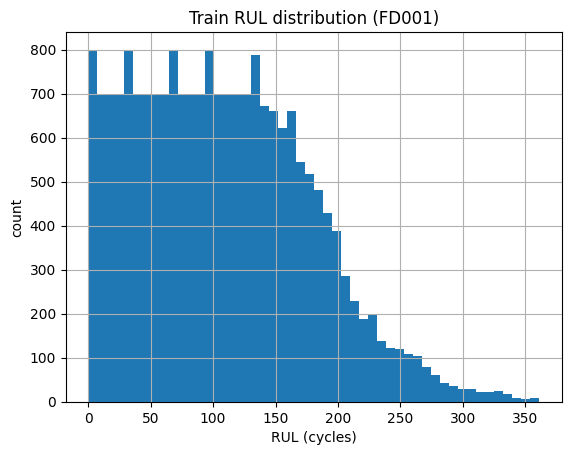

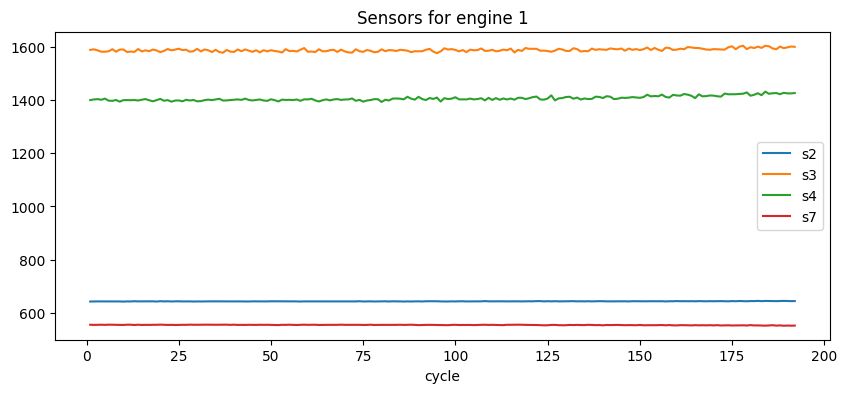

In [6]:
fig, ax = plt.subplots()
train["RUL"].hist(bins=50, ax=ax)
ax.set_title("Train RUL distribution (FD001)")
ax.set_xlabel("RUL (cycles)"); ax.set_ylabel("count")
plt.show()

# Plot a few sensor trajectories for one engine
sample_id = train["engine_id"].iloc[0]
eg = train[train.engine_id == sample_id]
eg.set_index("cycle")[["s2","s3","s4","s7"]].plot(figsize=(10,4), title=f"Sensors for engine {sample_id}")
plt.show()

# === 4) Feature Engineering (rolling window) ==================================


In [7]:
SENSOR_COLS = [c for c in train.columns if c.startswith("s")]
SET_COLS = [c for c in train.columns if c.startswith("op_setting_")]
FEAT_COLS = SENSOR_COLS + SET_COLS + ["cycle"]

def make_features(df, window=20):
    df = df.sort_values(["engine_id","cycle"]).copy()
    # Rolling mean/std per engine for sensors
    for c in SENSOR_COLS:
        df[f"{c}_mean{window}"] = df.groupby("engine_id")[c].transform(lambda x: x.rolling(window, min_periods=5).mean())
        df[f"{c}_std{window}"]  = df.groupby("engine_id")[c].transform(lambda x: x.rolling(window, min_periods=5).std())
        # simple trend (slope proxy): current - mean
        df[f"{c}_trend{window}"] = df[c] - df[f"{c}_mean{window}"]
    # Drop early rows with many NaNs from rolling
    df = df.groupby("engine_id").apply(lambda g: g.iloc[window:]).reset_index(drop=True)
    return df

train_f = make_features(train, window=20)
feature_cols = [c for c in train_f.columns if c.startswith(("s","op_setting_")) and c not in SENSOR_COLS]  # use engineered + op settings
len(feature_cols), feature_cols[:6]

/tmp/ipykernel_13/2019322553.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("engine_id").apply(lambda g: g.iloc[window:]).reset_index(drop=True)


(66,
 ['op_setting_1',
  'op_setting_2',
  'op_setting_3',
  's1_mean20',
  's1_std20',
  's1_trend20'])

# === 5) Validation & Baseline (Ridge + GroupKFold) ============================


In [8]:
X = train_f[feature_cols].fillna(method="ffill").fillna(method="bfill")
y = train_f["RUL"].values
groups = train_f["engine_id"].values

cv = GroupKFold(n_splits=5)
rmses = []
for fold, (tr, va) in enumerate(cv.split(X, y, groups), 1):
    m = Ridge(alpha=1.0, random_state=42)
    m.fit(X.iloc[tr], y[tr])
    p = m.predict(X.iloc[va])
    rmse = mean_squared_error(y[va], p, squared=False)
    rmses.append(rmse)
    print(f"Fold {fold} RMSE: {rmse:.2f}")
print("CV RMSE:", np.mean(rmses).round(2))
model = Ridge(alpha=1.0).fit(X, y)


Fold 1 RMSE: 45.29
Fold 2 RMSE: 43.48
Fold 3 RMSE: 38.34
Fold 4 RMSE: 39.34
Fold 5 RMSE: 36.65
CV RMSE: 40.62


/tmp/ipykernel_13/435985478.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X = train_f[feature_cols].fillna(method="ffill").fillna(method="bfill")


# === 6) Business Metric: Net Benefit (threshold sweep) ========================


In [9]:
T = 25  # alert if predicted RUL < T cycles
COST_FALSE_ALERT = 300     # preventive inspection cost
COST_MISSED_FAIL = 8000    # unplanned downtime cost proxy within horizon

# Build a per-engine last-row prediction to simulate "today's" decision
last_rows = train_f.groupby("engine_id").tail(1).copy()
last_rows["y_true"] = last_rows["RUL"]
last_rows["y_pred"] = model.predict(last_rows[feature_cols].fillna(0))

last_rows["alert"] = (last_rows["y_pred"] < T).astype(int)
last_rows["fail_within_T"] = (last_rows["y_true"] < T).astype(int)

tp = ((last_rows["alert"]==1) & (last_rows["fail_within_T"]==1)).sum()
fp = ((last_rows["alert"]==1) & (last_rows["fail_within_T"]==0)).sum()
fn = ((last_rows["alert"]==0) & (last_rows["fail_within_T"]==1)).sum()

net_benefit = tp*COST_MISSED_FAIL - fp*COST_FALSE_ALERT - fn*COST_MISSED_FAIL
pd.DataFrame({
    "TP":[tp], "FP":[fp], "FN":[fn],
    "Threshold_T":[T],
    "NetBenefit$":[net_benefit]
})


,TP,FP,FN,Threshold_T,NetBenefit$
0,100,0,0,25,800000


# === 7) Save Artifacts (model + meta) =========================================


In [10]:
import joblib, json
joblib.dump(model, WORK_DIR/"ridge_fd001.joblib")
meta = {"threshold_T": T, "cost_false_alert": COST_FALSE_ALERT, "cost_missed_fail": COST_MISSED_FAIL,
        "cv_rmse": float(np.mean(rmses))}
json.dump(meta, open(WORK_DIR/"meta.json","w"))
print("Saved:", list(WORK_DIR.iterdir()))


Saved: [PosixPath('/kaggle/working/meta.json'), PosixPath('/kaggle/working/__notebook__.ipynb'), PosixPath('/kaggle/working/ridge_fd001.joblib')]
